# **RETO#2 ALURA / Telecom X**


## EXTRACCION DE DATOS

###IMPORTAR DATOS Y VERIFICAR CHURN

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [4]:
#TOMAMOS LA DB https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json

In [5]:
#IMPORTAR DATOS DESDE GITHUB
url = 'https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json'
raw_url = url.replace('blob', 'raw')
df = pd.read_json(raw_url)
df.head(5)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
Vacio = df[df["Churn"] == ""]
#Vacio

Teniendo en cuenta que el dato de Churn es crucial para el analisis, no nos ayudaran las filas donde no se tenga uno, para facilitar el analisis de datos reemplazaremos los espacios sin datos por "Unknown", puesto que no sabemos el estado del usuario

In [7]:
df['Churn']=df['Churn'].map(lambda x: x.strip())

In [8]:
df['Churn']=df['Churn'].map(lambda x: x.replace('Yes','1').replace('No','0'))

In [9]:
df['Churn']=pd.to_numeric(df['Churn'], errors='coerce')

In [10]:
df['Churn']=df['Churn'].astype(str)

In [11]:
#COMPROBAR QUE TENEMOS DENTRO DE CHURN
df['Churn'].unique()

array(['0.0', '1.0', 'nan'], dtype=object)

In [12]:
df['Churn']=df['Churn'].map(lambda x: x.replace('nan','Unknown').replace('0.0','No').replace('1.0','Yes').strip())

In [13]:
df['Churn'].unique()

array(['No', 'Yes', 'Unknown'], dtype=object)

### ADECUACION DE CX

In [14]:
#EVIDENCIAR QUE DATOS ESTAN CONTENIDOS DENTRO DE CUSTOMER
datos_customer = pd.json_normalize(df['customer'])
#datos_customer

In [15]:
#datos_customer["tenure"].unique()

In [16]:
datos_customer["SeniorCitizen"] = datos_customer["SeniorCitizen"].astype(str)
datos_customer["SeniorCitizen"] = datos_customer["SeniorCitizen"].map(lambda x: x.replace('0','No').replace('1','Yes').strip())
datos_customer["SeniorCitizen"].unique()
datos_customer

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,No,Yes,Yes,9
1,Male,No,No,No,9
2,Male,No,No,No,4
3,Male,Yes,Yes,No,13
4,Female,Yes,Yes,No,3
...,...,...,...,...,...
7262,Female,No,No,No,13
7263,Male,No,Yes,No,22
7264,Male,No,No,No,2
7265,Male,No,Yes,Yes,67


Con esto dejamos solo nos datos necesarios como int y los otros como object, para tener una mejor uniformidad entre datos.

###ADECUACION DE PHONE

In [17]:
#EVIDENCIAR QUE DATOS ESTAN CONTENIDOS DENTRO DE PHONE
datos_phone = pd.json_normalize(df['phone'])
datos_phone

,PhoneService,MultipleLines
0,Yes,No
1,Yes,Yes
2,Yes,No
3,Yes,No
4,Yes,No
...,...,...
7262,Yes,No
7263,Yes,Yes
7264,Yes,No
7265,Yes,No


In [18]:
datos_phone["PhoneService"].unique()

array(['Yes', 'No'], dtype=object)

In [19]:
datos_phone["MultipleLines"]

,MultipleLines
0,No
1,Yes
2,No
3,No
4,No
...,...
7262,No
7263,Yes
7264,No
7265,No


In [20]:
Sinservicio = datos_phone[datos_phone["MultipleLines"] == "No phone service"]
#Sinservicio

Al evidenciar Phone fue posible encontrar que existe un tipo de clasificacion denominado "No phone service" dentro de MultipleLines, esto es redundante, por ello se obta por reemplazarlo por "No".

In [21]:
datos_phone["MultipleLines"] = datos_phone["MultipleLines"].map(lambda x: x.replace('No phone service','No').strip())
datos_phone["MultipleLines"].unique()

array(['No', 'Yes'], dtype=object)

###ADECUACION DE INTERNET

In [22]:
#EVIDENCIAR QUE DATOS ESTAN CONTENIDOS DENTRO DE internet
datos_inter = pd.json_normalize(df['internet'])
datos_inter.sample(20)

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
6119,Fiber optic,No,Yes,No,Yes,Yes,Yes
1586,Fiber optic,No,Yes,No,No,No,No
4711,DSL,Yes,No,No,Yes,No,No
2169,DSL,No,Yes,Yes,No,No,No
4665,DSL,Yes,No,Yes,Yes,Yes,No
317,DSL,Yes,Yes,Yes,No,Yes,Yes
259,DSL,Yes,Yes,Yes,No,No,No
4370,DSL,Yes,Yes,Yes,No,No,No
2546,Fiber optic,No,No,No,No,No,No
3589,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service


In [23]:
no_servicio = datos_inter[datos_inter['InternetService'] == 'No'].index
#datos_inter.drop(no_servicio, inplace=True)
no_servicio

Index([  20,   23,   24,   27,   28,   29,   32,   34,   36,   39,
       ...
       7239, 7244, 7245, 7247, 7248, 7250, 7252, 7256, 7257, 7261],
      dtype='int64', length=1581)

Hay personas afiliadas con la empresa que no cuentan con servicio de internet, esto es util puesto que con la lista de no_service, podremos descartar estos datos.

### ADECUACION DE ACCOUNT


In [24]:
datos_account= pd.json_normalize(df['account'])
datos_account.sample(10)

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
1081,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
5968,Month-to-month,Yes,Electronic check,35.65,425.1
4894,Month-to-month,Yes,Credit card (automatic),69.95,1205.5
4421,One year,Yes,Electronic check,106.50,7397
6707,Two year,No,Mailed check,35.10,770.4
4969,Month-to-month,Yes,Electronic check,49.40,611.65
6459,Month-to-month,Yes,Electronic check,49.15,169.05
7017,One year,Yes,Bank transfer (automatic),107.35,7051.95
5488,Month-to-month,No,Mailed check,44.80,220.45
756,Month-to-month,No,Bank transfer (automatic),69.75,69.75


In [25]:
datos_account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Contract          7267 non-null   object 
 1   PaperlessBilling  7267 non-null   object 
 2   PaymentMethod     7267 non-null   object 
 3   Charges.Monthly   7267 non-null   float64
 4   Charges.Total     7267 non-null   object 
dtypes: float64(1), object(4)
memory usage: 284.0+ KB


De estas dos celdas podemos extraer que, es necesario hacer un cambio de variable a la columna de "Charges.Total", puesto que se representaria mejor en valor numerico que en object.

In [26]:
datos_account["Charges.Total"] = datos_account["Charges.Total"].map(lambda x: x.strip())
datos_account["Charges.Total"] = pd.to_numeric(datos_account["Charges.Total"], errors='coerce')
datos_account["Charges.Total"].isnull().sum()

np.int64(11)

Al momento de realizar el cambio de variable, algunos de estos valores se volvieron nulos, para verificar si hay recibos previos verificamos con los datos del cliente:

In [27]:
Null_Charges = datos_account[datos_account["Charges.Total"].isnull()].index

In [28]:
Cx_sin_Total_Charges = datos_customer.loc[Null_Charges]
Cx_sin_Total_Charges = Cx_sin_Total_Charges[Cx_sin_Total_Charges["tenure"] == 0]
Cx_sin_Total_Charges

,gender,SeniorCitizen,Partner,Dependents,tenure
975,Female,No,Yes,Yes,0
1775,Female,No,Yes,Yes,0
1955,Male,No,No,Yes,0
2075,Male,No,Yes,Yes,0
2232,Male,No,No,Yes,0
2308,Male,No,Yes,Yes,0
2930,Female,No,Yes,Yes,0
3134,Male,No,Yes,Yes,0
3203,Female,No,Yes,Yes,0
4169,Female,No,Yes,Yes,0


Esto significa que no cuentan con un "Total charges" porque recien empezaron a pagar su servicio

###ESTANDARIZACION DE DATOS:

In [29]:
est_datos_account = datos_account.copy()
est_datos_internet = datos_inter.copy()
est_datos_customer = datos_customer.copy()
est_datos_phone = datos_phone.copy()

#### CLIENTE

In [30]:
est_datos_customer.iloc[:,1:4] = est_datos_customer.iloc[:,1:4].map(lambda x: x.replace('Yes','1').replace('No','0'))
#est_datos_customer

#### PHONE:

In [31]:
est_datos_phone[['MultipleLines','PhoneService']]=est_datos_phone[['MultipleLines','PhoneService']].map(lambda x: x.replace('No','0').replace('Yes','1').strip())
#est_datos_phone

#### INTERNET

In [32]:
est_datos_internet.iloc[:,1:]=est_datos_internet.iloc[:,1:].map(lambda x: x.replace('No','0').replace('Yes','1').strip())
#est_datos_internet

#### CUENTA

In [33]:
est_datos_account["PaperlessBilling"] = est_datos_account["PaperlessBilling"].map(lambda x: x.replace('Yes','1').replace('No','0'))
est_datos_account

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,One year,1,Mailed check,65.60,593.30
1,Month-to-month,0,Mailed check,59.90,542.40
2,Month-to-month,1,Electronic check,73.90,280.85
3,Month-to-month,1,Electronic check,98.00,1237.85
4,Month-to-month,1,Mailed check,83.90,267.40
...,...,...,...,...,...
7262,One year,0,Mailed check,55.15,742.90
7263,Month-to-month,1,Electronic check,85.10,1873.70
7264,Month-to-month,1,Mailed check,50.30,92.75
7265,Two year,0,Mailed check,67.85,4627.65


##CARGA Y ANALISIS DE DATOS

LO primero es evaluar que cantidad de usuarios siguen recibiendo el servicio y cuantos desertaron, para ello tomamos los datos del JSON, en el se encuentra la columna Churn, es posible evideciar los siguientes resultados:

In [35]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
Unknown,224


Se evidencia una cantidad de usuarios activos mucho menor al historico de usuarios. Para una mejor visualizacion se plantea la siguiente grafica:

/tmp/ipykernel_378/2692037147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Churn', y='Quantity', data=Usuarios_Activos, palette='viridis')


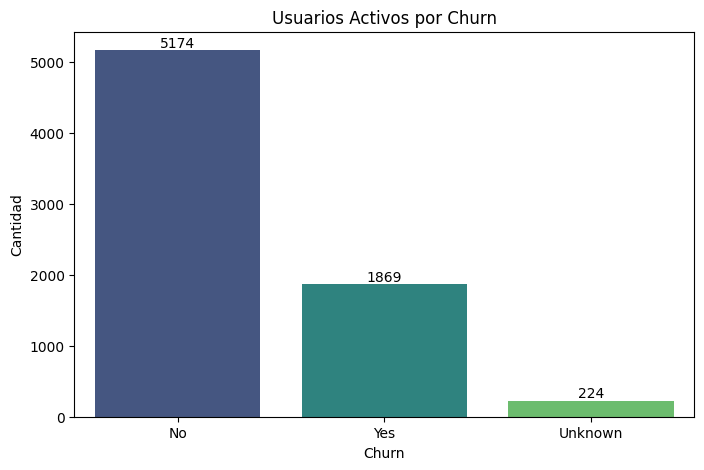

In [49]:
Usuarios_Activos = df["Churn"].value_counts().reset_index()
Usuarios_Activos.columns = ['Churn', 'Quantity']

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Churn', y='Quantity', data=Usuarios_Activos, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title("Usuarios Activos por Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad")
plt.show()

Se evidencia una amplia deserción por  parte de los usuarios, ahora para encontrar la razon debemos analizar a fondo el dataframe, para obtener alguna relacion entre los diferentes servicios y la decision de los usuarios.

In [102]:
DF_completo = df
DF_completo = DF_completo.drop(columns=['customer','phone','internet','account'])
DF_completo = pd.concat([DF_completo,est_datos_account,est_datos_internet,est_datos_customer,est_datos_phone], axis=1)
#CREACION DE DATAFRAME COMPLETO PARA LAS GRAFICAS SIGUIENTES
DF_completo


,customerID,Churn,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines
0,0002-ORFBO,No,One year,1,Mailed check,65.60,593.30,DSL,0,1,...,1,1,0,Female,0,1,1,9,1,0
1,0003-MKNFE,No,Month-to-month,0,Mailed check,59.90,542.40,DSL,0,0,...,0,0,1,Male,0,0,0,9,1,1
2,0004-TLHLJ,Yes,Month-to-month,1,Electronic check,73.90,280.85,Fiber optic,0,0,...,0,0,0,Male,0,0,0,4,1,0
3,0011-IGKFF,Yes,Month-to-month,1,Electronic check,98.00,1237.85,Fiber optic,0,1,...,0,1,1,Male,1,1,0,13,1,0
4,0013-EXCHZ,Yes,Month-to-month,1,Mailed check,83.90,267.40,Fiber optic,0,0,...,1,1,0,Female,1,1,0,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,One year,0,Mailed check,55.15,742.90,DSL,1,0,...,1,0,0,Female,0,0,0,13,1,0
7263,9992-RRAMN,Yes,Month-to-month,1,Electronic check,85.10,1873.70,Fiber optic,0,0,...,0,0,1,Male,0,1,0,22,1,1
7264,9992-UJOEL,No,Month-to-month,1,Mailed check,50.30,92.75,DSL,0,1,...,0,0,0,Male,0,0,0,2,1,0
7265,9993-LHIEB,No,Two year,0,Mailed check,67.85,4627.65,DSL,1,0,...,1,0,1,Male,0,1,1,67,1,0


### Análisis Descriptivo

A continuación, se presenta un análisis descriptivo de las columnas numéricas en el DataFrame, que incluye métricas como la media, la desviación estándar, los valores mínimos y máximos, y los cuartiles.

In [100]:
display(DF_completo.describe())

,Charges.Monthly,Charges.Total,tenure
count,7267.000000,7256.000000,7267.000000
mean,64.720098,2280.634213,32.346498
std,30.129572,2268.632997,24.571773
min,18.250000,18.800000,0.000000
25%,35.425000,400.225000,9.000000
50%,70.300000,1391.000000,29.000000
75%,89.875000,3785.300000,55.000000
max,118.750000,8684.800000,72.000000


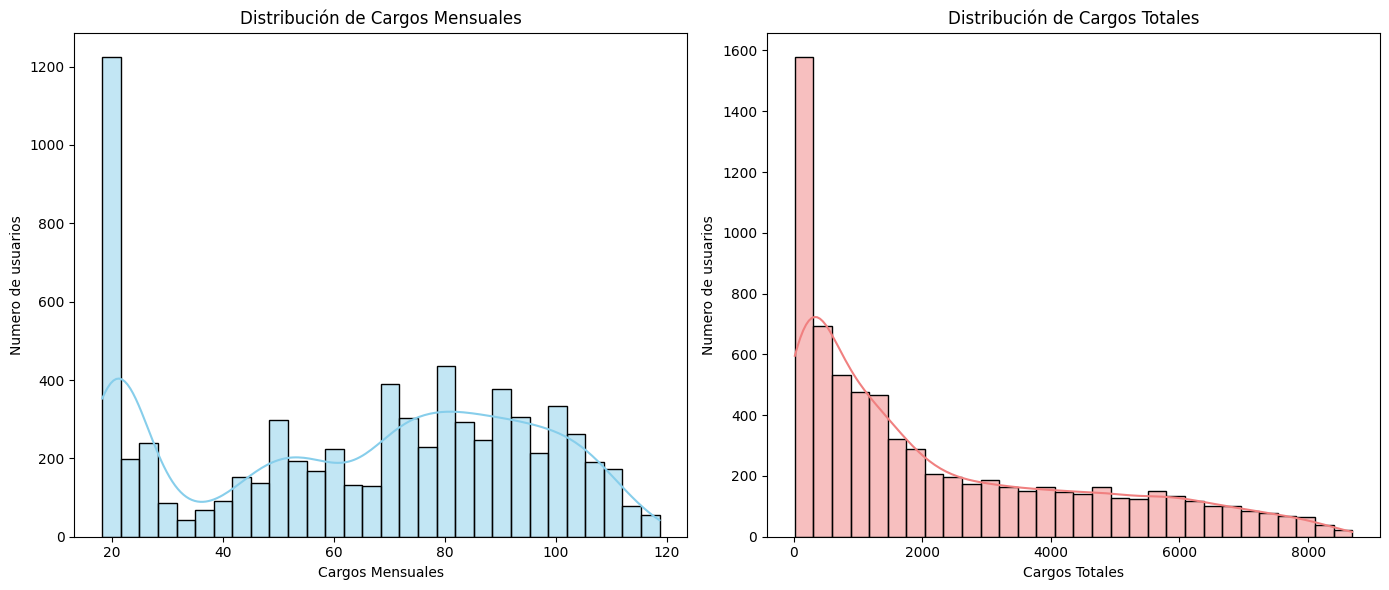

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Distribution plot for Charges.Monthly
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(DF_completo['Charges.Monthly'], kde=True, bins=30, color='skyblue')
plt.title('Distribución de Cargos Mensuales')
plt.xlabel('Cargos Mensuales')
plt.ylabel('Numero de usuarios')

# Distribution plot for Charges.Total
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(DF_completo['Charges.Total'].dropna(), kde=True, bins=30, color='lightcoral') # dropna() to handle NaN values
plt.title('Distribución de Cargos Totales')
plt.xlabel('Cargos Totales')
plt.ylabel('Numero de usuarios')

plt.tight_layout()
plt.show()

###Recuento de evasión por variables categóricas

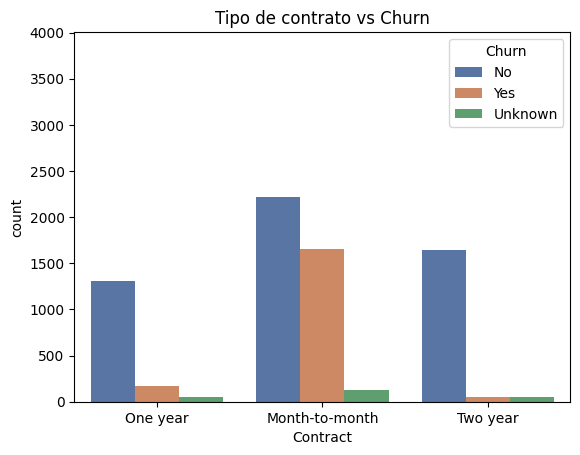

<Figure size 800x500 with 0 Axes>

In [79]:
ax = sns.countplot(x='Contract', hue='Churn', data=DF_completo, palette='deep')
max_val = DF_completo['Contract'].value_counts().max()
ax.set_ylim(0, max_val)
plt.title("Tipo de contrato vs Churn")
plt.show()

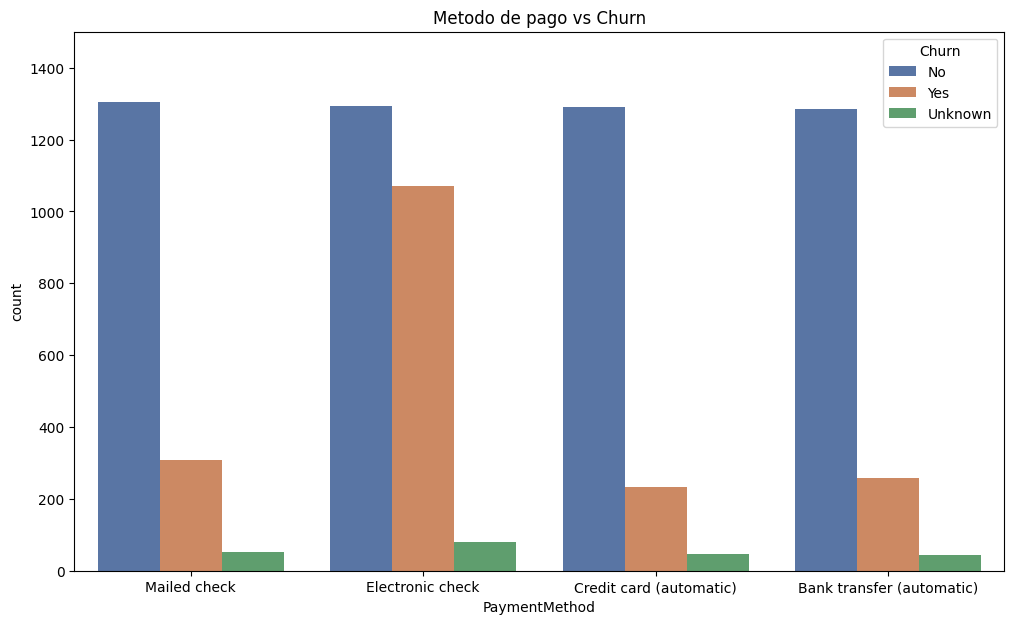

In [93]:
plt.figure(figsize=(12, 7))
ax = sns.countplot(x='PaymentMethod', hue='Churn', data=DF_completo, palette='deep')
max_val = DF_completo['PaymentMethod'].value_counts().max()
ax.set_ylim(0, 1500)
plt.title("Metodo de pago vs Churn")
plt.show()

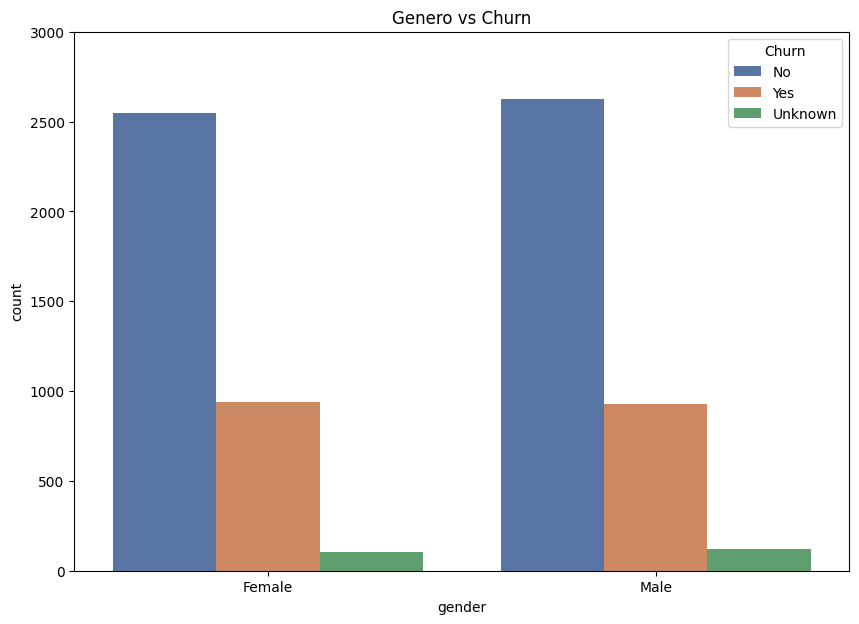

In [98]:
plt.figure(figsize=(10, 7))
ax = sns.countplot(x='gender', hue='Churn', data=DF_completo, palette='deep')
ax.set_ylim(0, 3000)
plt.title("Genero vs Churn")
plt.show()

###Recuento de evasión por variables numericas

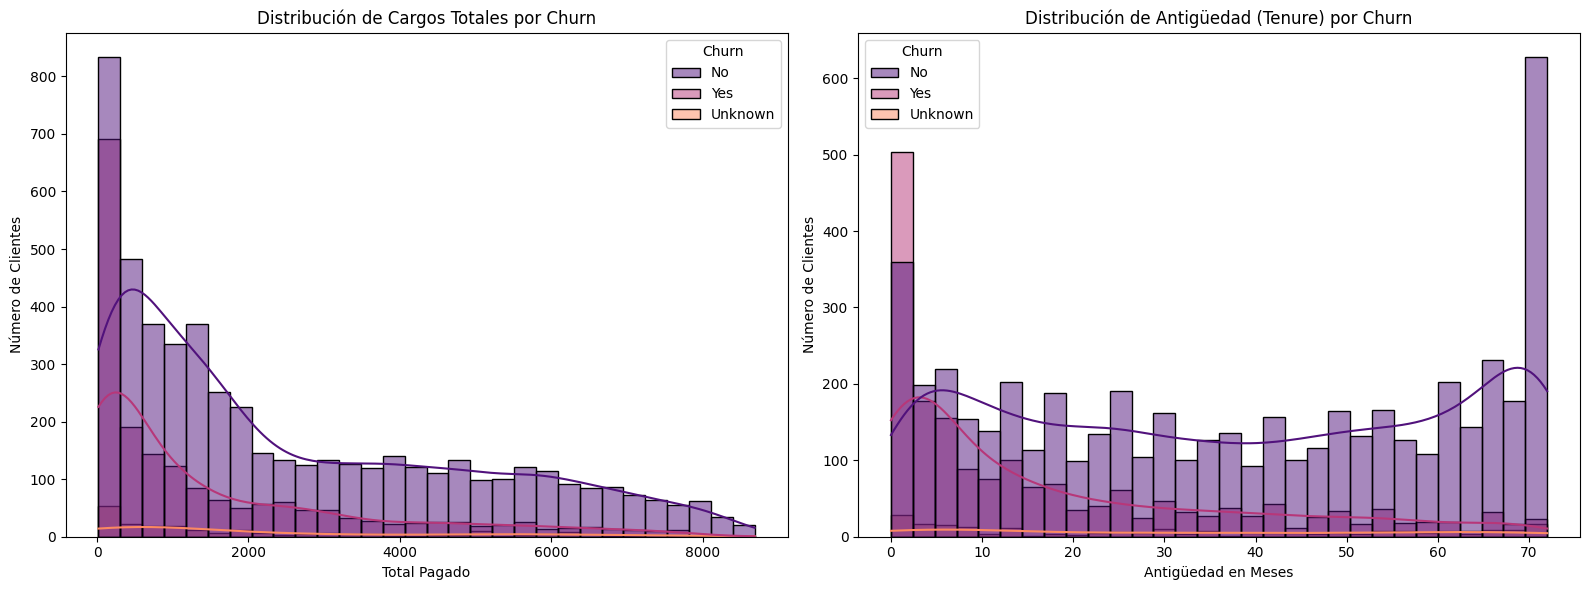

In [108]:
plt.figure(figsize=(16, 6))

# Distribution of Charges.Total by Churn
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(data=DF_completo.dropna(subset=['Charges.Total']), x='Charges.Total', hue='Churn', kde=True, bins=30, palette='magma')
plt.title('Distribución de Cargos Totales por Churn')
plt.xlabel('Total Pagado')
plt.ylabel('Número de Clientes')

# Distribution of Tenure by Churn
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(data=DF_completo, x='tenure', hue='Churn', kde=True, bins=30, palette='magma')
plt.title('Distribución de Antigüedad (Tenure) por Churn')
plt.xlabel('Antigüedad en Meses')
plt.ylabel('Número de Clientes')

plt.tight_layout()
plt.show()

### INFORME FINAL


## INFORME FINAL DEL ANÁLISIS DE CHURN EN TELECOM X

### 🔹 Introducción
El objetivo principal de este análisis es comprender los factores que influyen en la evasión de clientes en Telecom X. Identificar patrones y causas de desercion es crucial para desarrollar estrategias de retención efectivas.

### 🔹 Limpieza y Tratamiento de Datos
El proceso de análisis comenzó con la importación de los datos del archivo `TelecomX_Data.json` desde un repositorio de GitHub. Los datos se encontraban anidados en columnas de tipo diccionario (`customer`, `phone`, `internet`, `account`), por lo que fue necesario normalizarlos en DataFrames separados.

Se realizaron los siguientes pasos de limpieza y adecuación:
1.  **Columna Chur**: Se convirtió a un formato unificado de 'Yes', 'No' y 'Unknown' para los valores faltantes. Inicialmente se encontraron valores vacíos que fueron tratados para evitar errores en el análisis.
2.  **Columna customer**: Se normalizó para extraer `gender`, `SeniorCitizen`, `Partner`, `Dependents` y `tenure`. `SeniorCitizen` se transformó de 0/1 a 'No'/'Yes'.
3.  **Columna phone**: Se normalizó para extraer `PhoneService` y `MultipleLines`. Se corrigió la redundancia en `MultipleLines` reemplazando 'No phone service' por 'No'.
4.  **Columna internet**: Se normalizó para extraer los diferentes servicios de internet. Se identificaron clientes sin servicio de internet.
5.  **Columna account**: Se normalizó para extraer `Contract`, `PaperlessBilling`, `PaymentMethod`, `Charges.Monthly` y `Charges.Total`. La columna `Charges.Total` se convirtió a tipo numérico, y los valores nulos resultantes se identificaron como clientes con `tenure = 0`, indicando que son clientes nuevos sin cargos totales acumulados.
6.  **Estandarización de Datos**: Se transformaron las variables categóricas binarias (como `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `PaperlessBilling`, y los servicios de internet) a valores numéricos '0' y '1' para facilitar análisis posteriores y la construcción del DataFrame completo `DF_completo`.

### 🔹 Análisis Exploratorio de Datos
Se realizaron varias visualizaciones para entender la distribución de los datos y la relación con el Churn:
1.  **Distribución de Churn**: Se observó que la mayoría de los clientes no han abandonado el servicio, pero una parte significativa sí lo ha hecho, además de un grupo con estado 'Unknown'.
2.  **Distribución de Cargos Mensuales y Totales**: Los gráficos mostraron picos en los cargos mensuales bajos (servicios básicos) y altos (paquetes completos). Los cargos totales exhibieron una fuerte inclinación hacia valores bajos, indicando una gran cantidad de clientes con poca antigüedad o gasto acumulado.
3.  **Análisis de desercion por Variables Categóricas:**
    *   **Tipo de Contrato (Contract) vs desercion**: Se observó que los clientes con contratos mes a mes tienen una tasa de Churn significativamente más alta en comparación con los contratos de uno o dos años.
    *   **Método de Pago (PaymentMethod) vs desercion**: El método de pago 'Electronic check' mostró una mayor proporción de Churn en comparación con otros métodos.
    *   **Género (Gender) vs desercion**: No se encontró una diferencia sustancial en la tasa de desercion entre géneros.
4.  **Análisis de desercion por Variables Numéricas:**
    *   **Cargos Totales (Charges.Total) vs Churn**: Los clientes que hicieron Churn tienden a tener cargos totales acumulados más bajos, lo que sugiere que abandonan el servicio antes de acumular un historial de gasto considerable.
    *   **Antigüedad (Tenure) vs Churn**: Se evidenció que la mayoría de los clientes que cancelan lo hacen en los primeros meses de servicio. Los clientes con mayor antigüedad son significativamente menos propensos a hacer Churn.

### 🔹 Conclusiones e Insights
*   **Vulnerabilidad Temprana**: Los clientes nuevos (baja antigüedad) y aquellos con planes de bajo costo o contratos mensuales son los más propensos a la evasión. Esto es un insight crítico para la retención.
*   **Impacto de los Contratos**: Los contratos a corto plazo (mes a mes) están fuertemente asociados con una mayor tasa de Churn, lo que sugiere que la falta de compromiso a largo plazo es un factor de riesgo.
*   **Métodos de Pago**: El pago electrónico podría estar asociado a un segmento de clientes menos 'fidelizado' o más propenso a cambiar de proveedor rápidamente.

### 🔹 Recomendaciones
1.  **Programas de Retención Temprana**: Implementar estrategias proactivas para los clientes en sus primeros 6-12 meses de servicio, como ofertas especiales, seguimiento personalizado o beneficios por permanencia.
2.  **Incentivos para Contratos de Mayor Duración**: Ofrecer descuentos o beneficios atractivos para fomentar la contratación de planes de uno o dos años, reduciendo la exposición al riesgo de desercion mensual.
3.  **Mejora Continua del Servicio**: Dado que la desercion es alta en clientes nuevos, asegurar que la experiencia inicial del cliente sea impecable en términos de instalación, atención al cliente y funcionamiento del servicio.